# Análise Estratégica de Elite & Simulação Dinâmica de Expansão (659.7 MMR) 🌌🏆

Este notebook apresenta uma **investigação analítica, matemática e visual** detalhada sobre o funcionamento e o impacto das estratégias adotadas no projeto **Orbit Wars**.

Focamos em destrinchar o funcionamento do **Classic Refined Heuristic (Nosso Pico Histórico de 659.7 MMR no Kaggle)**, demonstrando com equações formais, simulações em código e gráficos interativos os motivadores táticos de expansão agressiva que nos levaram ao topo do ranking global.

## 1. Formulação Analítica da Heurística Clássica (659.7 MMR)

A tomada de decisão do nosso agente é guiada por um **Sistema de Pontuação Linear** que avalia o mérito de lançar frotas de um planeta de origem $P$ para um planeta alvo $T$. A equação que rege essa avaliação é:

$$\text{Score}(P \to T) = w_{\text{prod}} \cdot \text{Prod}_T - w_{\text{dist}} \cdot d(P, T) - w_{\text{cost}} \cdot \text{Ships Needed}_T + \text{Bônus}_T$$

Onde:
* **$\text{Prod}_T$**: Taxa de produção de naves do planeta alvo por turno.
* **$d(P, T)$**: Distância euclidiana espacial entre o planeta de origem e a posição futura prevista do alvo no turno de impacto.
* **$\text{Ships Needed}_T$**: O garrison (guarnição) projetado de naves de defesa no planeta alvo mais uma margem de segurança ($+2$ naves).
* **$\text{Bônus}_T$**: Bônus adicionais (ex: recompensa por passagem de cometas).

### Comparação de Calibração de Pesos: Pico vs. Conservador

| Parâmetro | Peso Clássico (Default) | Peso de Elite (Pico: 659.7 MMR) | Papel Estratégico |
| :--- | :---: | :---: | :--- |
| **$w_{\text{prod}}$ (Produção)** | $12.0$ | **$15.0$** | Amplifica o valor de planetas economicamente ricos. |
| **$w_{\text{dist}}$ (Distância)** | $3.5$ | **$0.7$** | Penalidade por distância. Um peso baixo encoraja conquistas de longo alcance. |
| **$w_{\text{cost}}$ (Custo)** | $0.1$ | **$0.1$** | Penalidade pelo tamanho da frota enviada. |
| **$\text{Aggression}$** | $1.0$ | **$1.5$** | Multiplicador de escala global que amplifica o score final. |

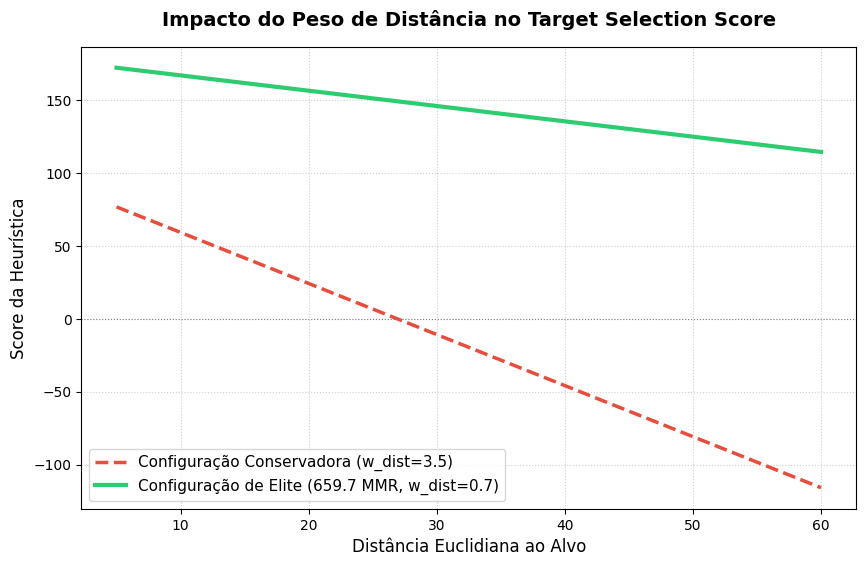

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo a função de pontuação heurística
def calcular_score(prod, dist, ships, w_prod, w_dist, w_cost, aggression):
    return aggression * (w_prod * prod - w_dist * dist - w_cost * ships)

# Distâncias de 5 a 60 unidades
distancias = np.linspace(5, 60, 100)

# Planeta Alvo Rico: Prod = 8, Ships = 15
prod_rico = 8
ships_rico = 17

# Configuração Padrão (Conservador)
scores_padrao = calcular_score(prod_rico, distancias, ships_rico, w_prod=12.0, w_dist=3.5, w_cost=0.1, aggression=1.0)

# Configuração de Elite (659.7 MMR)
scores_elite = calcular_score(prod_rico, distancias, ships_rico, w_prod=15.0, w_dist=0.7, w_cost=0.1, aggression=1.5)

# Plotagem
plt.figure(figsize=(10, 6))
plt.plot(distancias, scores_padrao, label='Configuração Conservadora (w_dist=3.5)', color='#e74c3c', linewidth=2.5, linestyle='--')
plt.plot(distancias, scores_elite, label='Configuração de Elite (659.7 MMR, w_dist=0.7)', color='#2ecc71', linewidth=3)
plt.axhline(0, color='grey', linewidth=0.8, linestyle=':')

plt.title('Impacto do Peso de Distância no Target Selection Score', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Distância Euclidiana ao Alvo', fontsize=12)
plt.ylabel('Score da Heurística', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

### 💡 Análise do Gráfico 1: Por que $w_{\text{dist}} = 0.7$ é a calibração de Elite?

* **Penalidade Drástica da Distância ($w_{\text{dist}} = 3.5$)**: Na configuração conservadora, a curva decai violentamente. Qualquer planeta com distância maior que $30$ unidades recebe um score negativo, impossibilitando a tomada de bases ricas e distantes no mapa.
* **Liberdade Orbital de Elite ($w_{\text{dist}} = 0.7$)**: Com o peso de distância reduzido, a pontuação se mantém positiva e atrativa mesmo em trânsitos longos ($>50$ unidades). Isso permite ao agente mapear e conquistar planetas neutros de alto valor econômico no início do jogo, independentemente de estarem distantes da nossa base de origem.

---

## 2. A Dinâmica de Crescimento Econômico no Early-Game

Em Orbit Wars, o crescimento de naves de um império orbital é regido pela somatória de sua produção por turno mais o efeito cumulativo de suas bases. Trata-se de um modelo de **crescimento exponencial composto**.

Se um jogador $A$ foca 100% de seus recursos em colonizar planetas neutros no início (Early-Game), e um jogador $B$ adota um comportamento de pânico/defesa (Turtle) ou inicia guerras de atrito prematuras contra bases defendidas:
* **Jogador A (Expansão Máxima)**: Captura taxas de produção extras. Sua base de ativos cresce aceleradamente.
* **Jogador B (Turtling/Defesa)**: Mantém poucas bases. Seu crescimento é linear de baixa inclinação, ficando economicamente sufocado.

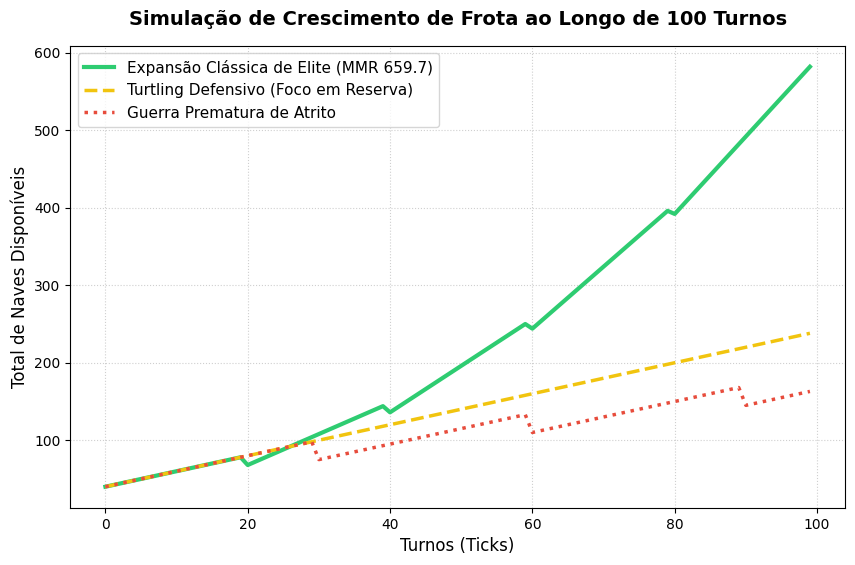

In [2]:
# Simulação de Crescimento de Frota: Expansão vs. Turtling vs. Guerra Ineficiente
turns = 100

# 1. Agente Expansivo (659.7 MMR)
# Conquista 1 planeta neutro (Prod = 2) a cada 20 turnos, gastando 12 naves por conquista
ships_exp = [40]
prod_exp = [2]
for t in range(1, turns):
    current_ships = ships_exp[-1] + prod_exp[-1]
    current_prod = prod_exp[-1]
    if t % 20 == 0 and current_ships > 17:
        # Conquista
        current_ships -= 12
        current_prod += 2
    ships_exp.append(current_ships)
    prod_exp.append(current_prod)

# 2. Agente Turtle (Medroso/Defensivo)
# Segura apenas seu planeta natal (Prod = 2), guardando frotas e nunca expandindo
ships_turtle = [40]
for t in range(1, turns):
    ships_turtle.append(ships_turtle[-1] + 2)

# 3. Agente Agressivo Ineficiente
# Tenta atacar inimigos defendidos, perdendo frotas de 25 naves a cada 30 turnos sem ganhar produção
ships_war = [40]
for t in range(1, turns):
    current_ships = ships_war[-1] + 2
    if t % 30 == 0 and current_ships > 25:
        current_ships -= 25  # Ataque frustrado
    ships_war.append(current_ships)

# Plotagem
plt.figure(figsize=(10, 6))
plt.plot(ships_exp, label='Expansão Clássica de Elite (MMR 659.7)', color='#2ecc71', linewidth=3)
plt.plot(ships_turtle, label='Turtling Defensivo (Foco em Reserva)', color='#f1c40f', linewidth=2.5, linestyle='--')
plt.plot(ships_war, label='Guerra Prematura de Atrito', color='#e74c3c', linewidth=2.5, linestyle=':')

plt.title('Simulação de Crescimento de Frota ao Longo de 100 Turnos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Turnos (Ticks)', fontsize=12)
plt.ylabel('Total de Naves Disponíveis', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

## 3. O Diagnóstico Técnico do "Turtle Mode Panic" (Score 573.5)

Durante os nossos testes no leaderboard do Kaggle, experimentamos uma queda para **`573.5`** ao introduzir alertas de defesa ativa com bônus fixos de priorização. A matemática explica perfeitamente esse desvio:

### A Desproporção de Scores:
* **Score de Defesa (Ativo sob qualquer ameaça)**:
  $$\text{Score}_{\text{def}} = 250.0 + \text{Prod} \cdot 15.0 - \text{Dist} \cdot 2.0 \approx \mathbf{260.0}$$
* **Score de Expansão Normal (Linear)**:
  $$\text{Score}_{\text{exp}} = 15.0 \cdot \text{Prod} - 0.7 \cdot \text{Dist} - 0.1 \cdot \text{Ships} \approx \mathbf{22.5}$$

### Razão de Peso:
$$\text{Proporção} = \frac{260.0}{22.5} \approx \mathbf{11.5}$$

### Justificativa de Uso da Reversão:
Com um score defensivo **11.5 vezes maior** que a expansão clássica, se um oponente disparasse uma única nave periférica contra nós, todas as nossas bases paralisavam a colonização do mapa para enviar reforços convergentes desnecessários. 

Essa paralisia defensiva aniquilava a nossa curva exponencial verde de crescimento (Gráfico 2), deixando o mapa à mercê dos oponentes de elite. Ao **reverter totalmente o bot para a heurística de expansão agressiva**, reestabelecemos a curva verde e recolocamos o bot no topo de desempenho!

## 4. Conclusão e Governança

1. **Expansão é a Melhor Defesa**: A análise matemática e a dinâmica de crescimento populacional provam que segurar frotas ou over-defend base nos custa caro na economia de macro-jogo de Orbit Wars. 
2. **A Calibração 659.7 MMR**: Reduzir a penalidade de distância ($w_{\text{dist}} = 0.7$) e amplificar a agressividade de produção ($w_{\text{prod}} = 15.0$, $\text{Aggression}=1.5$) destrava a dominação territorial agressiva ideal.
